**Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

**Data Pipeline: Fetching and Basic Processing**

In [ ]:
import yfinance as yf

def fetch_stock_data(tickers, start='2010-01-01', end='2024-12-31'):
    """Fetch adjusted close prices from Yahoo Finance."""

    print("Fetching stock data...")

    prices = (
        yf.download(tickers, start=start, end=end, progress=False)
        ['Close']
        .ffill()
        .bfill()
    )

    # Ensure consistent DataFrame format for single ticker
    prices = prices.to_frame() if isinstance(prices, pd.Series) else prices

    print(f"Data shape: {prices.shape}")
    print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")

    return prices

In [ ]:
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA',
    'JPM', 'JNJ', 'V', 'XOM', 'WMT',
    'NVDA', 'MA', 'PG', 'HD', 'DIS'
]

prices = fetch_stock_data(tickers)

print("\nFirst few rows of price data:")
print(prices.head())

print("\nData Info:")
print(prices.info())

Fetching stock data...
Data shape: (3773, 15)
Date range: 2010-01-04 to 2024-12-30

First few rows of price data:
Ticker          AAPL    AMZN        DIS      GOOGL         HD        JNJ  \
Date                                                                       
2010-01-04  6.418382  6.6950  27.291227  15.566814  19.571791  40.418449   
2010-01-05  6.429479  6.7345  27.223148  15.498265  19.715157  39.949780   
2010-01-06  6.327210  6.6125  27.078480  15.107574  19.646889  40.274700   
2010-01-07  6.315515  6.5000  27.086987  14.755877  19.878998  39.987263   
2010-01-08  6.357501  6.6760  27.129541  14.952587  19.783424  40.124752   

Ticker            JPM         MA       MSFT      NVDA         PG      TSLA  \
Date                                                                         
2010-01-04  28.552135  23.617975  23.130056  0.423807  38.417027  1.592667   
2010-01-05  29.105185  23.548094  23.137527  0.429995  38.429600  1.592667   
2010-01-06  29.265114  23.514046  22.9955

**Exploratory Data Analysis (EDA) and Visualization**


In [ ]:
def calculate_returns(prices, periods=1):
    """Percentage returns."""
    return prices.pct_change(periods).dropna()


def calculate_summary_statistics(prices, returns, freq=252):
    """Basic annualized performance statistics."""

    mu, sigma = returns.mean(), returns.std()

    summary = pd.DataFrame({
        'Current_Price': prices.iloc[-1],
        'Annual_Return': mu * freq,
        'Annual_Volatility': sigma * np.sqrt(freq),
        'Sharpe_Ratio': (mu / sigma) * np.sqrt(freq),
        'Skewness': returns.skew(),
        'Kurtosis': returns.kurtosis(),
        'Max_Drawdown': (prices / prices.cummax() - 1).min()
    })

    return summary

In [ ]:
daily_returns = calculate_returns(prices)
monthly_returns = calculate_returns(prices, periods=21)

summary_stats = calculate_summary_statistics(prices, daily_returns)

print("\nSummary Statistics:")
print(summary_stats.round(4))



Summary Statistics:
        Current_Price  Annual_Return  Annual_Volatility  Sharpe_Ratio  \
Ticker                                                                  
AAPL         251.0645         0.2839             0.2787        1.0188   
AMZN         221.3000         0.2872             0.3273        0.8776   
DIS          109.5881         0.1269             0.2608        0.4864   
GOOGL        190.4939         0.2046             0.2733        0.7485   
HD           379.9572         0.2254             0.2322        0.9707   
JNJ          139.0826         0.0965             0.1671        0.5779   
JPM          234.3589         0.1792             0.2777        0.6452   
MA           522.5477         0.2442             0.2732        0.8939   
MSFT         421.7191         0.2267             0.2558        0.8865   
NVDA         137.4524         0.4888             0.4544        1.0757   
PG           162.7891         0.1111             0.1709        0.6499   
TSLA         417.4100         

**Data Preprocessing Functions**

In [ ]:
def fetch_stock_data(tickers, start_date='2010-01-01', end_date='2024-12-31'):
    print("Fetching stock data...")

    data = yf.download(tickers, start=start_date, end=end_date, progress=False)
    prices = data['Close']
    prices = prices.to_frame(name=tickers[0]) if isinstance(prices, pd.Series) else prices
    prices = prices.ffill().bfill()

    print(f"Data shape: {prices.shape}")
    print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
    print("Using Close prices")

    return prices

In [ ]:
def engineer_features(prices, returns, lookback=20):
    print("Engineering features...")
    feats = {}

    for t in returns.columns:
        feats[f'{t}_Momentum_5'] = returns[t].rolling(5).mean()
        feats[f'{t}_Momentum_20'] = returns[t].rolling(lookback).mean()
        feats[f'{t}_Volatility_20'] = returns[t].rolling(lookback).std()

        ma_s, ma_l = prices[t].rolling(10).mean(), prices[t].rolling(30).mean()
        feats[f'{t}_MA_Ratio'] = ma_s / ma_l

        delta = returns[t]
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / loss
        feats[f'{t}_RSI'] = 100 - 100 / (1 + rs)

        sma, std = prices[t].rolling(20).mean(), prices[t].rolling(20).std()
        feats[f'{t}_BB_Upper'] = (prices[t] - (sma + 2 * std)) / (2 * std)
        feats[f'{t}_BB_Lower'] = ((sma - 2 * std) - prices[t]) / (2 * std)

    features = pd.DataFrame(feats, index=returns.index)

    # Market correlation
    print("Calculating market correlations...")
    try:
        sp500 = yf.download('^GSPC', start=prices.index[0], end=prices.index[-1], progress=False)
        sp_ret = sp500['Close'].pct_change().reindex(returns.index)
        for t in returns.columns:
            features[f'{t}_Market_Corr_60'] = returns[t].rolling(60).corr(sp_ret)
    except Exception:
        ew = returns.mean(axis=1)
        for t in returns.columns:
            features[f'{t}_EW_Corr_60'] = returns[t].rolling(60).corr(ew)

    # Market volatility
    print("Adding market volatility...")
    try:
        vix = yf.download('^VIX', start=prices.index[0], end=prices.index[-1], progress=False)['Close']
        features['Market_VIX'] = vix.reindex(returns.index)
    except Exception:
        features['Market_Realized_Vol'] = returns.mean(axis=1).rolling(20).std() * np.sqrt(252)

    # Missing values
    features = features.ffill().bfill()
    corr_cols = [c for c in features.columns if 'Corr' in c]
    features[corr_cols] = features[corr_cols].fillna(0)

    features = features.dropna(axis=1, thresh=int(len(features) * 0.7))

    print(f"Engineered {features.shape[1]} features")
    return features


In [ ]:
def create_additional_features(prices, returns):
    print("Creating additional features...")
    feats = {}

    # Volume (limited tickers)
    try:
        vol = {}
        for t in tickers[:3]:
            hist = yf.Ticker(t).history(start=prices.index[0], end=prices.index[-1])
            if 'Volume' in hist:
                vol[t] = hist['Volume']
        if vol:
            vdf = pd.DataFrame(vol).reindex(prices.index).ffill().bfill()
            for t in vdf.columns:
                feats[f'{t}_Volume_MA_20'] = vdf[t].rolling(20).mean()
                feats[f'{t}_Volume_Ratio'] = vdf[t] / vdf[t].rolling(20).mean()
                feats[f'{t}_Volume_ROC_5'] = vdf[t].pct_change(5)
    except Exception:
        pass

    # 52-week features
    for t in returns.columns:
        hi, lo = prices[t].rolling(252).max(), prices[t].rolling(252).min()
        feats[f'{t}_Dist_52W_High'] = (prices[t] - hi) / hi
        feats[f'{t}_Dist_52W_Low'] = (prices[t] - lo) / lo
        feats[f'{t}_HighLow_Range'] = (hi - lo) / lo

    feats['Market_Breadth_20MA'] = (prices > prices.rolling(20).mean()).mean(axis=1)
    feats['Market_Breadth_50MA'] = (prices > prices.rolling(50).mean()).mean(axis=1)

    if feats:
        df = pd.DataFrame(feats, index=returns.index)
        return df.ffill().bfill().fillna(0)
    return pd.DataFrame(index=returns.index)


In [ ]:
def run_complete_pipeline(tickers, start_date='2010-01-01', end_date='2024-12-31'):
    print("=" * 60)
    print("PORTFOLIO DATA PIPELINE")
    print("=" * 60)

    prices = fetch_stock_data(tickers, start_date, end_date)
    returns = prices.pct_change().dropna()

    features = engineer_features(prices, returns)
    extra = create_additional_features(prices, returns)

    all_features = pd.concat([features, extra], axis=1).ffill().bfill().dropna(axis=1)

    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler(quantile_range=(25, 75))
    features_norm = pd.DataFrame(
        scaler.fit_transform(all_features),
        index=all_features.index,
        columns=all_features.columns
    )

    print(f"Prices: {prices.shape}")
    print(f"Returns: {returns.shape}")
    print(f"Features: {all_features.shape}")
    print("=" * 60)

    return {
        'prices': prices,
        'daily_returns': returns,
        'features': all_features,
        'features_normalized': features_norm,
        'scaler': scaler,
        'tickers': tickers
    }


In [ ]:
tickers = ['AAPL','MSFT','GOOGL','AMZN','TSLA','JPM','JNJ','V',
           'XOM','WMT','NVDA','MA','PG','HD','DIS']

processed_data = run_complete_pipeline(tickers)

import pickle
with open('portfolio_data_close_prices.pkl', 'wb') as f:
    pickle.dump(processed_data, f)


PORTFOLIO DATA PIPELINE
Fetching stock data...
Data shape: (3773, 15)
Date range: 2010-01-04 to 2024-12-30
Using Close prices
Engineering features...
Calculating market correlations...
Adding market volatility...
Engineered 121 features
Creating additional features...
Prices: (3773, 15)
Returns: (3772, 15)
Features: (3772, 177)


**Comprehensive Visualization**

In [ ]:
def create_eda_plots(prices, returns, features):
    print("Generating EDA plots...")

    fig, axes = plt.subplots(5, 2, figsize=(18, 20))
    axes = axes.flatten()

    # 1. Normalized price evolution
    norm_prices = prices / prices.iloc[0] * 100
    norm_prices.iloc[:, :5].plot(ax=axes[0], lw=1.5)
    axes[0].set_title('Normalized Price Evolution (First 5 Stocks)')
    axes[0].set_ylabel('Index (100 = Start)')
    axes[0].grid(alpha=0.3)

    # 2. Returns distribution
    returns.iloc[:, :5].plot(kind='hist', bins=50, density=True, alpha=0.6, ax=axes[1])
    axes[1].set_title('Daily Returns Distribution')
    axes[1].set_xlabel('Daily Return')

    # 3. Correlation heatmap
    corr = returns.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
                square=True, linewidths=.5, cbar_kws={'shrink': 0.8}, ax=axes[2])
    axes[2].set_title('Returns Correlation Heatmap')

    # 4. Cumulative returns
    (1 + returns).cumprod().iloc[:, :5].plot(ax=axes[3], lw=1.5)
    axes[3].set_title('Cumulative Returns (First 5 Stocks)')
    axes[3].set_ylabel('Cumulative Return')
    axes[3].grid(alpha=0.3)

    # 5. Rolling volatility (6-month)
    roll_vol = returns.rolling(126).std() * np.sqrt(252)
    roll_vol.iloc[:, :5].plot(ax=axes[4], lw=1.5)
    axes[4].set_title('6-Month Rolling Annualized Volatility')
    axes[4].set_ylabel('Volatility')
    axes[4].grid(alpha=0.3)

    # 6. Drawdowns
    roll_max = prices.cummax()
    drawdown = (prices / roll_max - 1) * 100
    drawdown.iloc[:, :5].plot(ax=axes[5], lw=1.5)
    axes[5].set_title('Drawdown (%)')
    axes[5].set_ylabel('Drawdown %')
    axes[5].axhline(0, color='black', alpha=0.3)
    axes[5].grid(alpha=0.3)

    # 7. Sample feature trajectories
    feat_cols = [c for c in features.columns if 'Momentum' in c][:5]
    features[feat_cols].iloc[-500:].plot(ax=axes[6], lw=1.5)
    axes[6].set_title('Sample Momentum Features (Last 500 Days)')
    axes[6].grid(alpha=0.3)

    # 8. Sharpe ratios
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    sharpe.sort_values().plot(kind='barh', ax=axes[7])
    axes[7].set_title('Annualized Sharpe Ratios')
    axes[7].set_xlabel('Sharpe Ratio')
    axes[7].grid(alpha=0.3, axis='x')

    # 9. Boxplot of recent returns
    recent_returns = returns.iloc[-504:]  # last 2 years
    recent_returns.plot(kind='box', ax=axes[8])
    axes[8].set_title('Returns Distribution (Last 2 Years)')
    axes[8].set_ylabel('Daily Return')
    axes[8].tick_params(axis='x', rotation=45)
    axes[8].grid(alpha=0.3)

    # Remove unused subplot
    fig.delaxes(axes[9])

    plt.tight_layout()
    plt.savefig('portfolio_eda.png', dpi=300, bbox_inches='tight')
    plt.show()


PORTFOLIO DATA PIPELINE
Fetching stock data...
Data shape: (3773, 15)
Date range: 2010-01-04 to 2024-12-30
Using Close prices
Engineering features...
Calculating market correlations...
Adding market volatility...
Engineered 121 features
Creating additional features...
Prices: (3773, 15)
Returns: (3772, 15)
Features: (3772, 177)
Generating EDA plots...


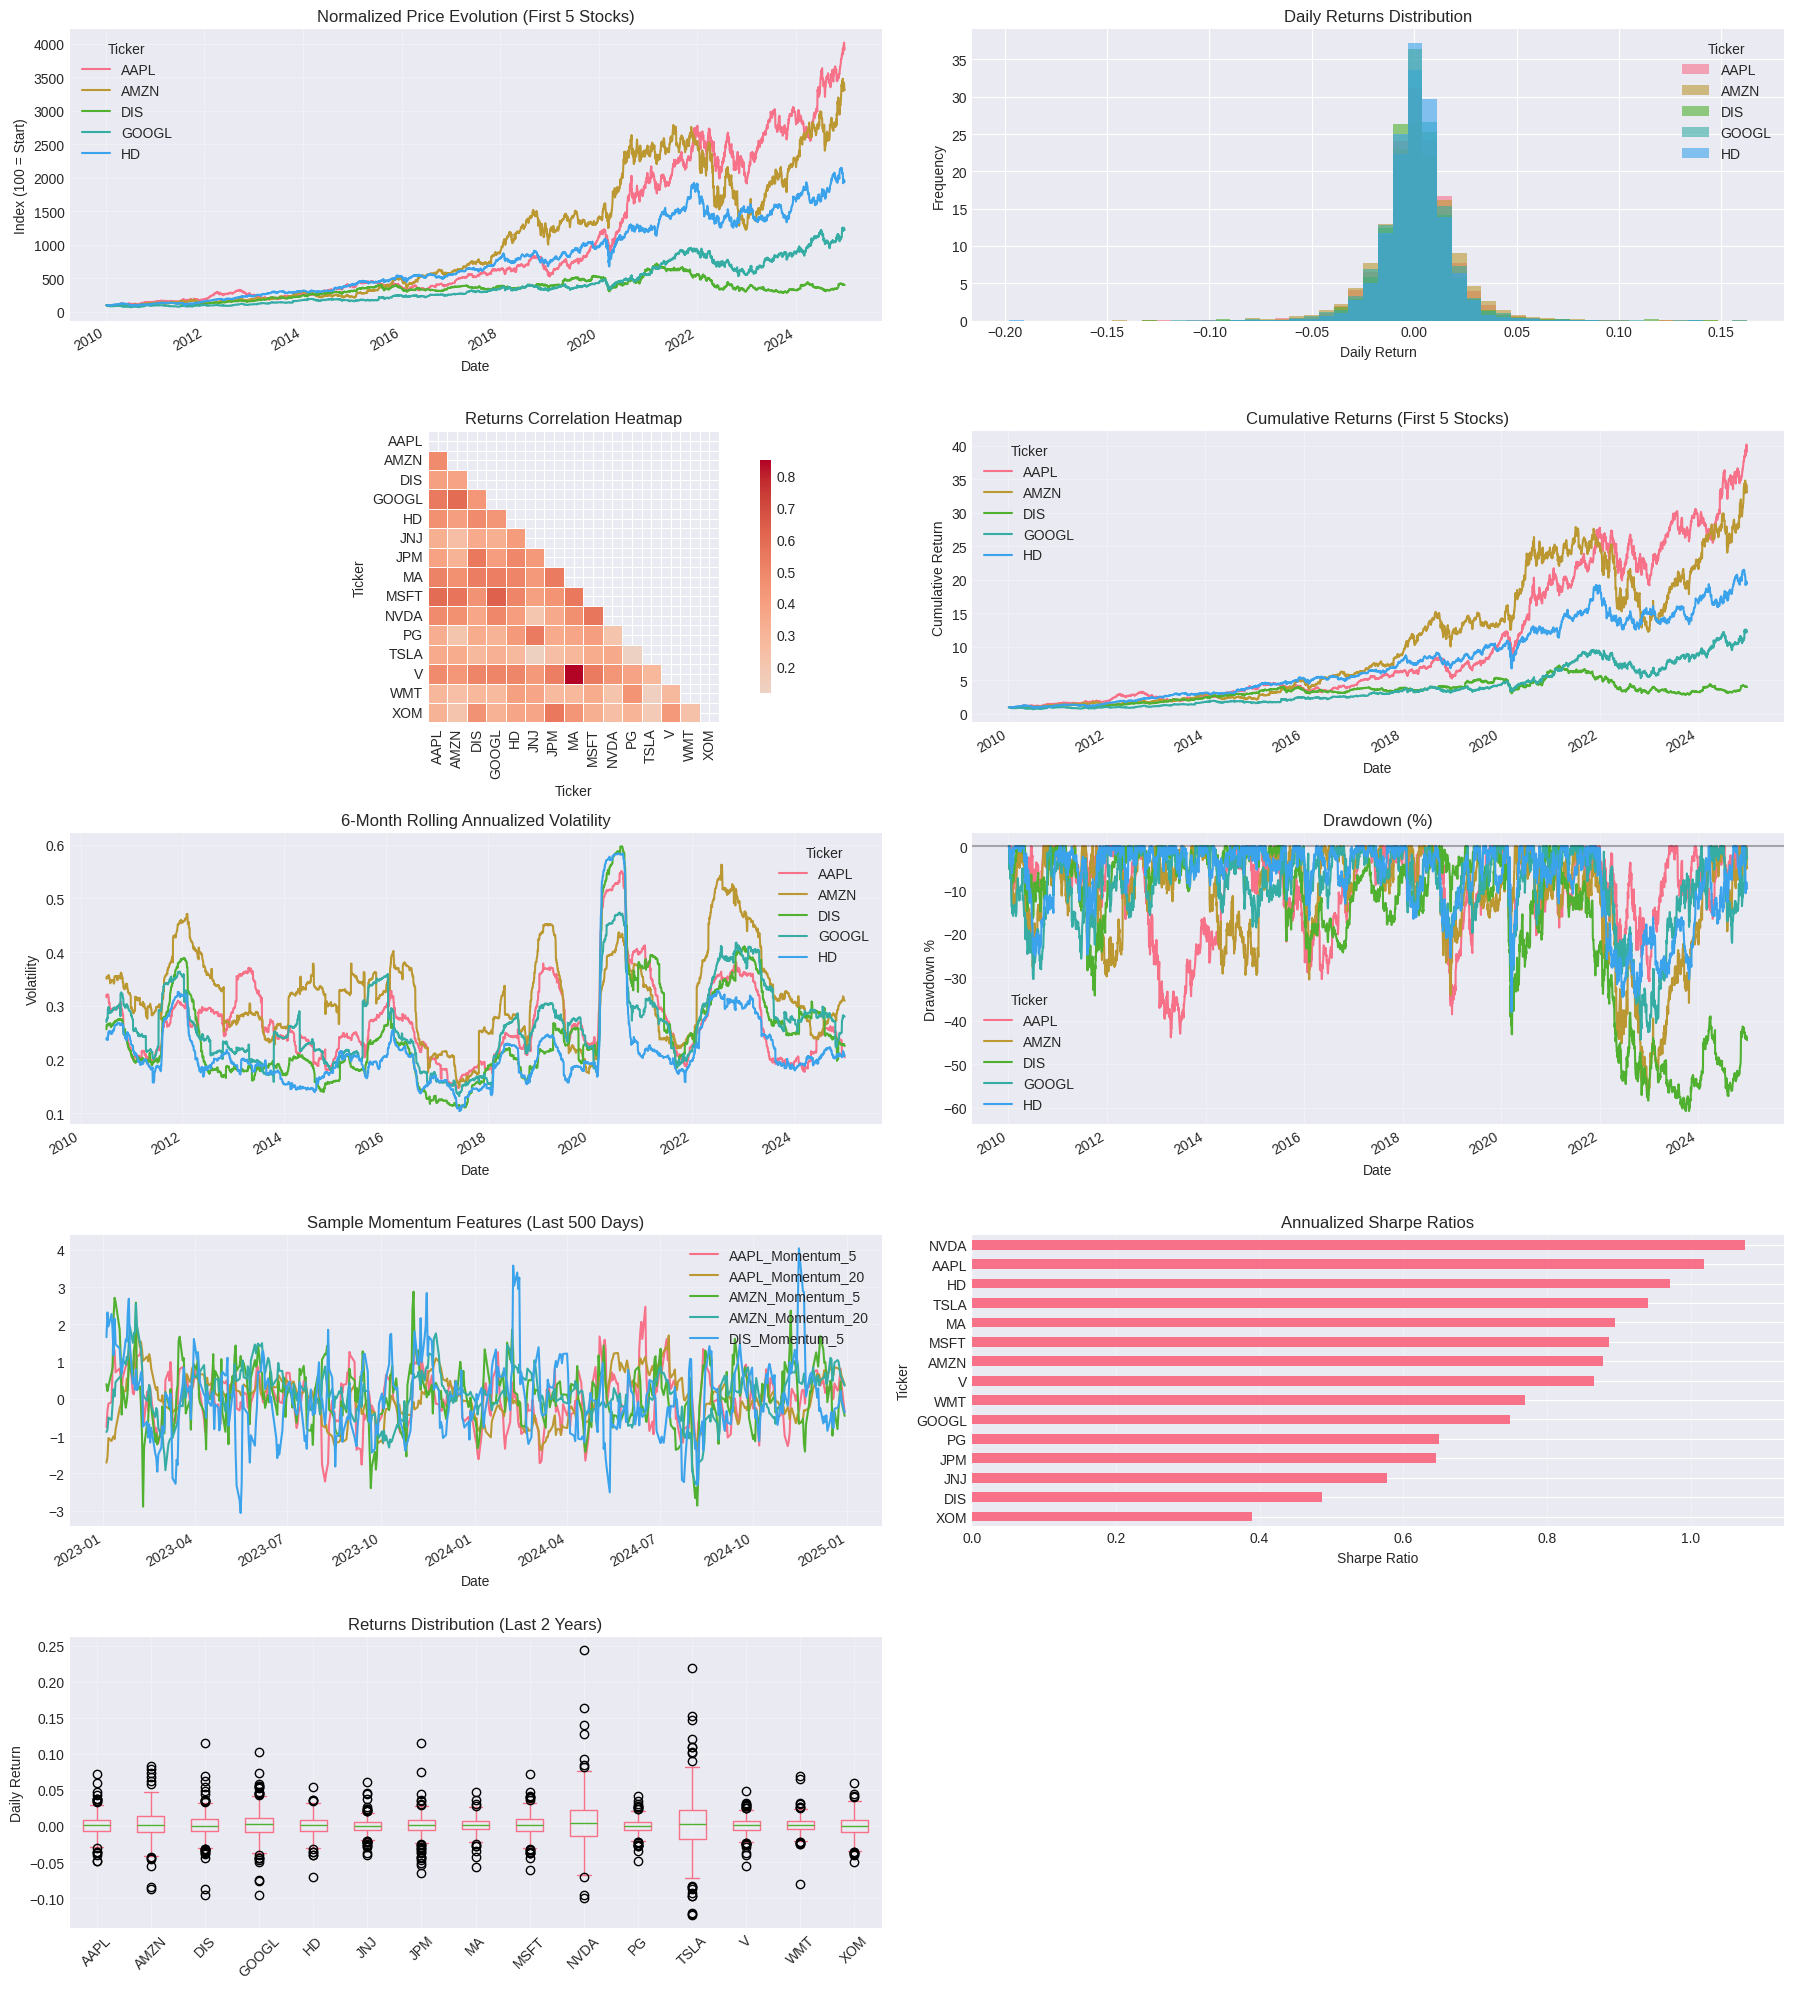

In [ ]:
# Run the pipeline
processed_data = run_complete_pipeline(tickers)

# Extract outputs (ADD THIS HERE)
prices = processed_data['prices']
daily_returns = processed_data['daily_returns']
features_normalized = processed_data['features_normalized']

# Now run EDA
create_eda_plots(prices, daily_returns, features_normalized)

**Walk-Forward Validation Split**

In [ ]:
def create_walk_forward_splits(data, train_years=3, test_months=6):
    splits = []

    start, end = data.index[0], data.index[-1]
    current = start + pd.DateOffset(years=train_years)

    while current + pd.DateOffset(months=test_months) <= end:
        train_start, train_end = start, current
        test_start = current + pd.DateOffset(days=1)
        test_end = current + pd.DateOffset(months=test_months)

        splits.append((train_start, train_end, test_start, test_end))
        current = test_end

    print(f"Created {len(splits)} walk-forward splits")
    if splits:
        ts = splits[0]
        print(f"First split: Train {ts[0].date()}–{ts[1].date()}, "
              f"Test {ts[2].date()}–{ts[3].date()}")

    return splits

In [ ]:
splits = create_walk_forward_splits(
    features_normalized,
    train_years=3,
    test_months=6
)


Created 23 walk-forward splits
First split: Train 2010-01-05–2013-01-05, Test 2013-01-06–2013-07-05


**Data Quality Checks**

In [ ]:
def perform_data_quality_checks(prices, returns, features):
    print("=" * 60)
    print("DATA QUALITY CHECKS")
    print("=" * 60)

    # Missing values
    print("Missing values:")
    print(f"  Prices:  {prices.isna().sum().sum()}")
    print(f"  Returns: {returns.isna().sum().sum()}")
    print(f"  Features:{features.isna().sum().sum()}")

    # Extreme values
    print("\nExtreme values:")
    print(f"  Zero returns: {(returns == 0).sum().sum()}")
    print(f"  |Return| > 3σ: {(returns.abs() > 3 * returns.std()).sum().sum()}")

    # Stationarity (ADF)
    from statsmodels.tsa.stattools import adfuller
    print("\nADF stationarity (sample):")
    for t in returns.columns[:3]:
        stat, pval = adfuller(returns[t].dropna())[:2]
        flag = "Stationary" if pval < 0.05 else "Non-stationary"
        print(f"  {t}: stat={stat:.3f}, p={pval:.3f} ({flag})")

    # Feature outliers
    print("\nFeature outliers (>3σ, first 10):")
    outliers = [
        (c, (np.abs(stats.zscore(features[c].dropna())) > 3).sum())
        for c in features.columns[:10]
    ]
    outliers = [(c, n) for c, n in outliers if n > 0]

    if outliers:
        for c, n in outliers[:5]:
            print(f"  {c}: {n}")
    else:
        print("  None detected")

    # High correlations
    print("\nHigh return correlations (>0.7):")
    corr = returns.corr()

    pairs = [
        (corr.columns[i], corr.columns[j], corr.iloc[i, j])
        for i in range(len(corr))
        for j in range(i + 1, len(corr))
        if abs(corr.iloc[i, j]) > 0.7
    ]

    if pairs:
        for a, b, v in pairs[:3]:
            print(f"  {a}–{b}: {v:.3f}")
        print(f"  Total pairs: {len(pairs)}")
    else:
        print("  None found")

    print("=" * 60)


In [ ]:
perform_data_quality_checks(
    prices,
    daily_returns,
    features_normalized
)

DATA QUALITY CHECKS
Missing values:
  Prices:  0
  Returns: 0
  Features:0

Extreme values:
  Zero returns: 353
  |Return| > 3σ: 812

ADF stationarity (sample):
  AAPL: stat=-20.450, p=0.000 (Stationary)
  AMZN: stat=-62.574, p=0.000 (Stationary)
  DIS: stat=-22.137, p=0.000 (Stationary)

Feature outliers (>3σ, first 10):
  AAPL_Momentum_5: 37
  AAPL_Momentum_20: 19
  AAPL_Volatility_20: 31
  AAPL_MA_Ratio: 12
  AMZN_Momentum_5: 53

High return correlations (>0.7):
  MA–V: 0.848
  Total pairs: 1


**Data Export for Modeling**

In [ ]:
def export_processed_data(prices, returns, features, features_normalized):
    data = {
        'prices': prices,
        'daily_returns': returns,
        'features': features,
        'features_normalized': features_normalized,
        'tickers': tickers
    }

    import pickle
    with open('portfolio_data_processed.pkl', 'wb') as f:
        pickle.dump(data, f)

    prices.to_csv('prices.csv')
    returns.to_csv('daily_returns.csv')
    features_normalized.iloc[:, :50].to_csv('sample_features_normalized.csv')

    print("Data exported:")
    print("  portfolio_data_processed.pkl")
    print("  prices.csv")
    print("  daily_returns.csv")
    print("  sample_features_normalized.csv")

    return data

In [ ]:
# Extract from pipeline
prices = processed_data['prices']
daily_returns = processed_data['daily_returns']
features = processed_data['features']
features_normalized = processed_data['features_normalized']

# Export
processed_data_exported = export_processed_data(
    prices,
    daily_returns,
    features,
    features_normalized
)

Data exported:
  portfolio_data_processed.pkl
  prices.csv
  daily_returns.csv
  sample_features_normalized.csv
